<a href="https://colab.research.google.com/github/fadeeva/Risk_Alpha_Stable/blob/main/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from scipy import stats

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# EDA

## Data

In [23]:
url = 'https://github.com/fadeeva/Risk_Alpha_Stable/raw/refs/heads/main/data/'

data = {
    'btc-usd': pd.read_csv(f'{url}btc-usd.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'gold': pd.read_csv(f'{url}gold.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'spy' : pd.read_csv(f'{url}spy.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'tlt': pd.read_csv(f'{url}tlt.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'usdrub': pd.read_csv(f'{url}usdrub.csv', parse_dates=True, index_col=0, header=[0, 1]),
}

for ticker in data.keys():
    data[ticker]['log_return'] = np.log(data[ticker]['Close'].div(data[ticker]['Close'].shift(1)))
    data[ticker].dropna(axis=0, inplace=True)


In [ ]:
data['gold'].head()

Price,Close,High,Low,Open,Volume,log_return
Ticker,GOLD,GOLD,GOLD,GOLD,GOLD,
Date,,,,,,
2023-01-04,31.236534,31.549350,30.797342,30.797342,139200,0.014160
2023-01-05,31.263428,31.496468,30.474671,31.030384,115600,0.000861
2023-01-06,32.867828,32.984350,31.424766,31.595064,287700,0.050045
2023-01-09,33.065014,34.902456,32.634784,33.378726,234800,0.005981
2023-01-10,33.477322,34.248152,32.572046,33.065018,307700,0.012393


## Visualization

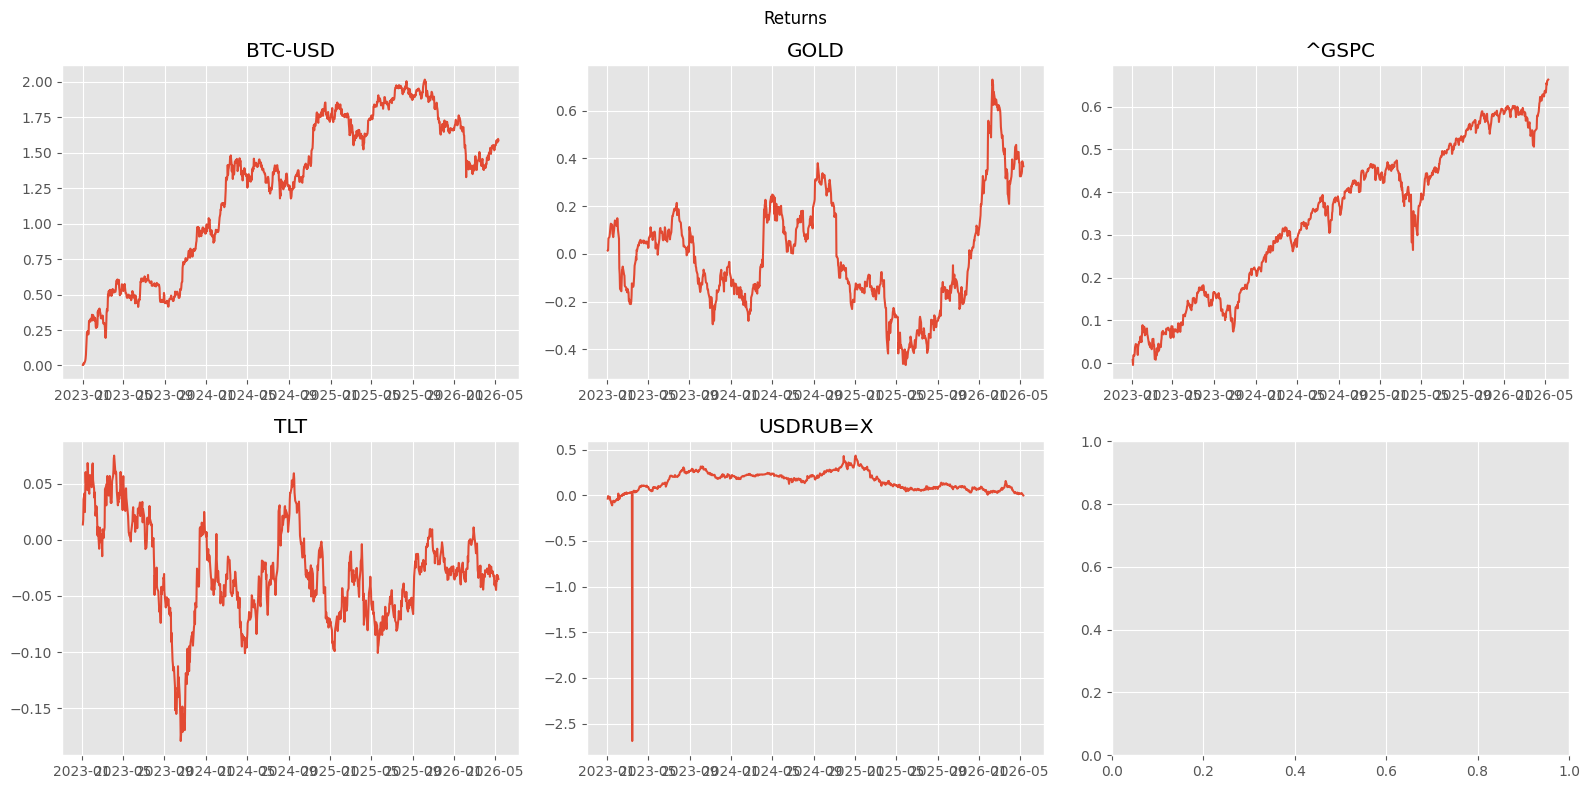

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, asset in enumerate(data.values()):
    axes[idx].plot(asset['log_return'].cumsum())
    axes[idx].set_title(f'{asset.columns[0][1]}')

plt.suptitle('Returns')
plt.tight_layout();

In [5]:
data['usdrub'].describe()

Price,Close,High,Low,Open,Volume,log_return
Ticker,USDRUB=X,USDRUB=X,USDRUB=X,USDRUB=X,USDRUB=X,
count,870.000000,870.000000,870.000000,870.000000,870.0,870.000000
mean,86.190639,86.996428,85.644843,86.258515,0.0,-0.000003
std,8.869125,8.585153,8.306890,8.466774,0.0,0.131240
min,5.000000,68.839996,65.964996,65.964996,0.0,-2.717538
25%,79.496151,80.110569,78.922920,79.493174,0.0,-0.006300
50%,85.925636,87.003918,85.044941,85.925835,0.0,0.000000
75%,92.097498,92.440002,91.701519,92.118752,0.0,0.006761
max,113.722176,114.999664,110.472549,113.728767,0.0,2.727395


In [11]:
data['usdrub'][data['usdrub']['log_return']==data['usdrub']['log_return'].min()]

Price,Close,High,Low,Open,Volume,log_return
Ticker,USDRUB=X,USDRUB=X,USDRUB=X,USDRUB=X,USDRUB=X,
Date,,,,,,
2023-03-16,5.0,77.038498,75.760498,76.065002,0,-2.717538


<Axes: xlabel='Date'>

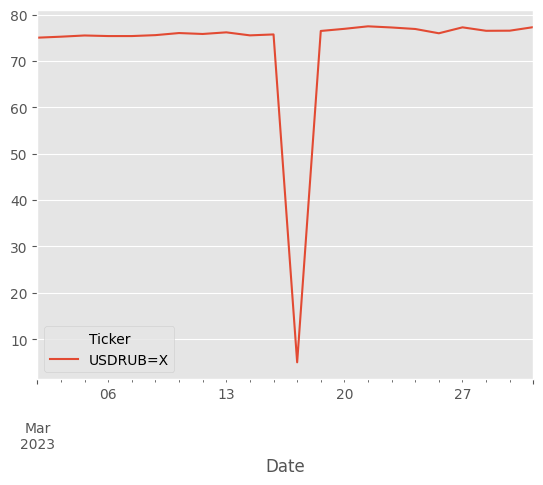

In [9]:
data['usdrub']['Close'].loc['2023-03-01':'2023-03-30'].plot()

In [24]:
data['usdrub'].drop(['2023-03-16', '2023-03-17'], inplace=True)
data['usdrub'].drop(['log_return'], axis=1, inplace=True)

data['usdrub']['log_return'] = np.log(data['usdrub']['Close'].div(data['usdrub']['Close'].shift(1)))
data[ticker].dropna(axis=0, inplace=True)

<Axes: xlabel='Date'>

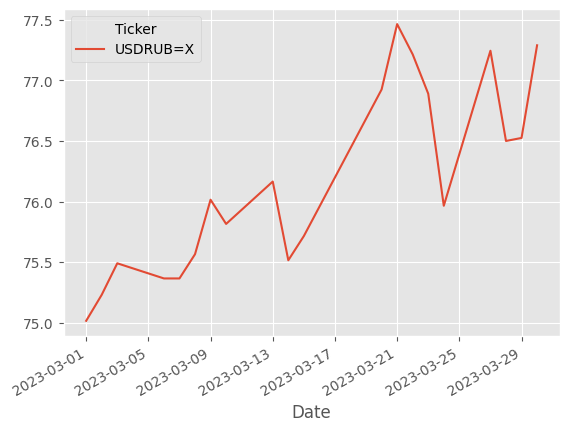

In [28]:
data['usdrub']['Close'].loc['2023-03-01':'2023-03-30'].plot()

### Visual analysis of tails

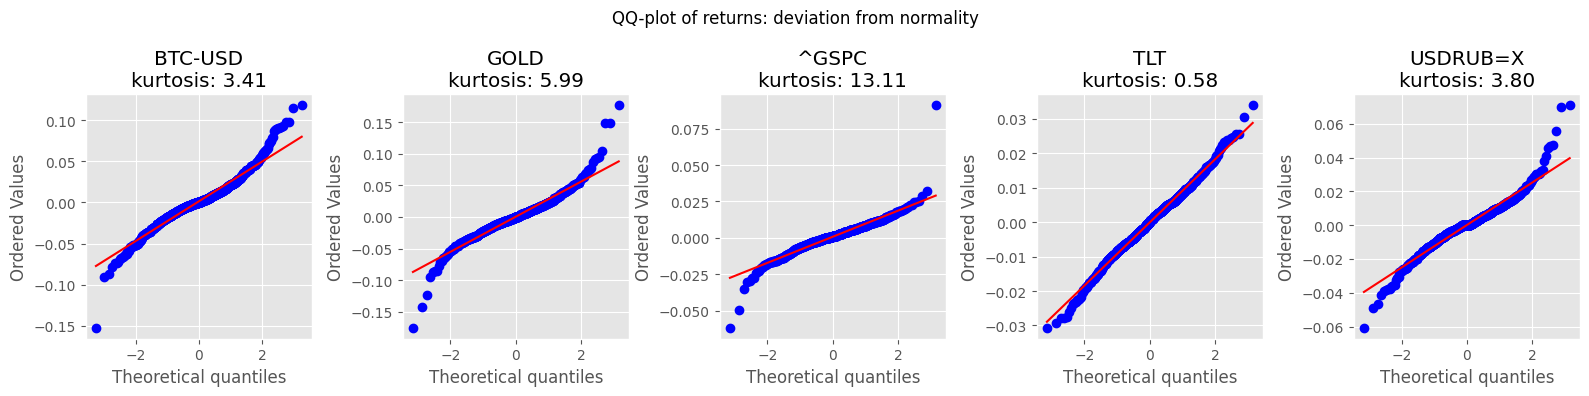

In [29]:
fig, axes = plt.subplots(1, len(data.keys()), figsize=(16, 4))

for idx, asset in enumerate(data.values()):
    stats.probplot(asset['log_return'], dist='norm', plot=axes[idx])
    axes[idx].set_title(f'{asset.columns[0][1]}\nkurtosis: {stats.kurtosis(asset['log_return']):.2f}')

plt.suptitle('QQ-plot of returns: deviation from normality')
plt.tight_layout();

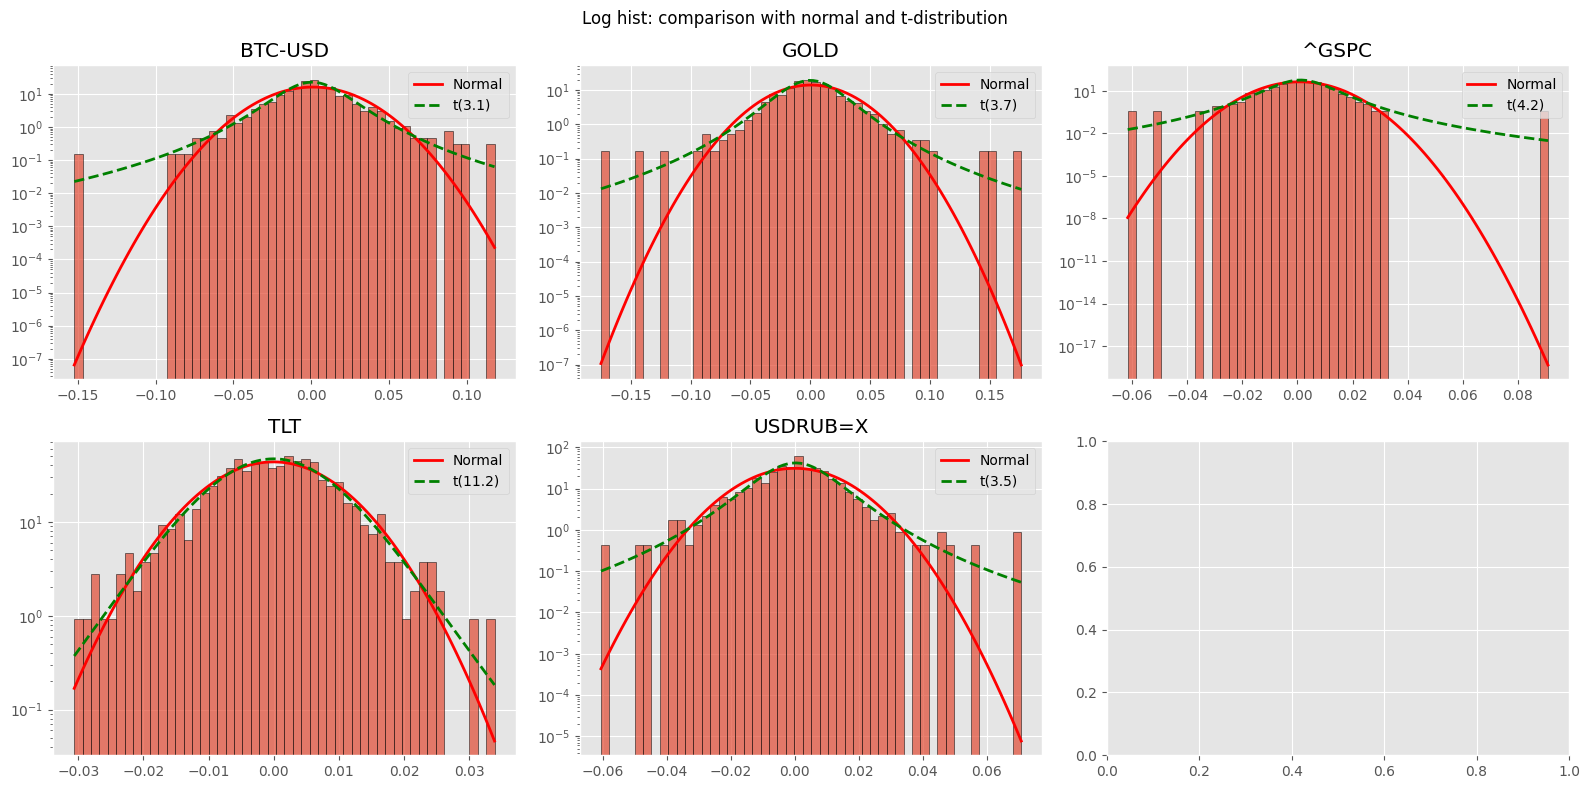

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, asset in enumerate(data.values()):
    axes[idx].hist(asset['log_return'], bins=50, density=True, alpha=.7, edgecolor='black')

    # normal distribution
    x = np.linspace(asset['log_return'].min(), asset['log_return'].max(), 100)
    axes[idx].plot(x, stats.norm.pdf(x, asset['log_return'].mean(), asset['log_return'].std()),
                  'r', lw=2, label='Normal')

    # t-distribution (fat tails)
    df, loc, scale = stats.t.fit(asset['log_return'])
    axes[idx].plot(x, stats.t.pdf(x, df, loc, scale), 'g--', lw=2, label=f't({df:.1f})')

    axes[idx].set_yscale('log')
    axes[idx].set_title(f'{asset.columns[0][1]}')
    axes[idx].legend(fontsize=10)

plt.suptitle('Log hist: comparison with normal and t-distribution')
plt.tight_layout()